In [21]:
import tensorflow as tf
import numpy as np
import re
import os

# Function to read and parse the tensor data from a text file
def parse_tensor_from_file(file_path, shape):
    with open(file_path, 'r') as file:
        # Read the content of the file
        tensor_str = file.read()
    components = re.findall(r"([+-]?\d+\.?\d*[eE]?[+-]?\d*(?:\s*[+-]?\d*\.?\d*[eE]?[+-]?\d*j)?)", tensor_str)

    # Convert the components into a numpy array of complex numbers
    complex_numbers = [complex(c.replace(' ','')) for c in components]

    # Convert the list to a NumPy array and reshape it
    numpy_tensor = np.array(complex_numbers, dtype=np.complex128)

    if (shape == 3):
        numpy_tensor = numpy_tensor.reshape(round(numpy_tensor.size ** (1/shape)),round(numpy_tensor.size ** (1/shape)),round(numpy_tensor.size ** (1/shape)))
    if (shape == 2):
        size = numpy_tensor.size
        new_shape = (round(size ** (1/shape)), round(size ** (1/shape))) if shape == 2 else (size,)
        numpy_tensor = numpy_tensor.reshape(new_shape)
    # Convert NumPy array to TensorFlow tensor
    tf_tensor = tf.convert_to_tensor(numpy_tensor)

    return tf_tensor
def retrieve_dict(base_dir, filename):
    # Dictionary to hold costs organized by prefix (i)
    fidelity_dict = {}
    # Iterate through each subfolder in the base directory
    folder_names = os.listdir(base_dir)
    
    # Sort folders numerically or lexicographically
    folder_names.sort(key=lambda x: int(x.split('_')[0]))

    # Iterate through each subfolder in the base directory
    for folder_name_1 in folder_names:
        folder_path = os.path.join(base_dir, folder_name_1)
        if os.path.isdir(folder_path):
            # Extract the prefix for identifying the 'i' value
            prefix = folder_name_1.split('_')[0]
            folder_paths = os.listdir(folder_path)
            directories = [item for item in folder_paths if os.path.isdir(os.path.join(folder_path, item))]
            print(directories)
            directories.sort(key=lambda x: float(x.split('_')[-1]))
            for folder_name_2 in directories:
                 
                 folder_path_2 = os.path.join(folder_path, folder_name_2)
                 cost_file_path = os.path.join(folder_path_2, filename)
            
                # Read the cost value from the cost.txt file
                 if os.path.exists(cost_file_path):
                        # Extract the complex number part using regular expression
                        tensor = parse_tensor_from_file(cost_file_path, 1)
                        print(cost_file_path)
                        # Convert the extracted string to a complex number
                        for t in tensor.numpy():
                             # Get the real part and convert to float
                            float_value = 1-t.real
                            # if (float_value < 10e-4): continue
                            if prefix not in fidelity_dict:
                                fidelity_dict[prefix] = []
                            fidelity_dict[prefix].append(abs(float_value))
    
    return fidelity_dict

['_1.00', '_0.30', '_0.05', '_0.20', '_0.65', '_0.70', '_0.95', '_0.40', '_0.90', '_0.00', '_0.60', '_0.25', '_0.75', '_0.15', '_0.10', '_0.80', '_0.35', '_0.45', '_0.55', '_0.85', '_0.50']
../../results/experiment_new/dephasing/1_qubits/_0.00/mean_fidelity_rho_rho3.txt
../../results/experiment_new/dephasing/1_qubits/_0.05/mean_fidelity_rho_rho3.txt
../../results/experiment_new/dephasing/1_qubits/_0.10/mean_fidelity_rho_rho3.txt
../../results/experiment_new/dephasing/1_qubits/_0.15/mean_fidelity_rho_rho3.txt
../../results/experiment_new/dephasing/1_qubits/_0.20/mean_fidelity_rho_rho3.txt
../../results/experiment_new/dephasing/1_qubits/_0.25/mean_fidelity_rho_rho3.txt
../../results/experiment_new/dephasing/1_qubits/_0.30/mean_fidelity_rho_rho3.txt
../../results/experiment_new/dephasing/1_qubits/_0.35/mean_fidelity_rho_rho3.txt
../../results/experiment_new/dephasing/1_qubits/_0.40/mean_fidelity_rho_rho3.txt
../../results/experiment_new/dephasing/1_qubits/_0.45/mean_fidelity_rho_rho3.txt


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


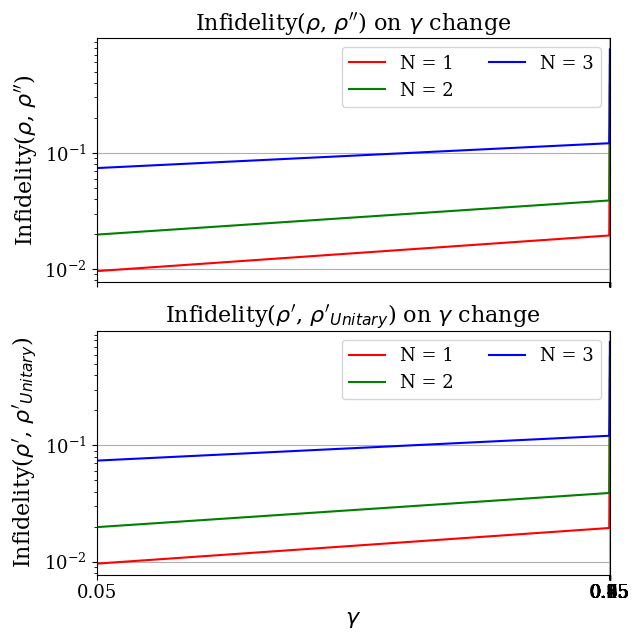

In [23]:
import matplotlib.pyplot as plt


def plot_fidelity(fidelity_dict1, fidelity_dict2, ylabel1, ylabel2, xlabel, file_name):
    # Set font family to serif
    plt.rc('font', family='serif')
    # Create a figure with two subplots stacked vertically
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.5, 6.5), sharex=True)
    colorList = ['r', 'g', 'b', 'magenta', 'orange']
    ax2.set_xscale('log')
    # Plot for the first fidelity dict on the first subplot (top plot)
    for i, (key, values) in enumerate(fidelity_dict1.items()):
        ax1.plot(values[1:], label="N = " + key, color=colorList[i % len(colorList)])  # Use color cycling for variety

    # Adding labels and title to the first plot
    ax1.set_ylabel(ylabel1, fontsize=16)
    ax1.set_title(ylabel1 + ' on ' + xlabel + ' change', fontsize=16)  # Optional: title for the first plot
    ax1.set_yscale('log')  # Set y-axis to logarithmic scale
    ax1.grid(True)
    ax1.legend(fontsize=13, ncol=2)
    
    # Plot for the second fidelity dict on the second subplot (bottom plot)
    for i, (key, values) in enumerate(fidelity_dict2.items()):
        ax2.plot(values[1:], label="N = " + key, color=colorList[i % len(colorList)])

    # Adding labels and title to the second plot
    ax2.set_xlabel(xlabel, fontsize=16)  # Shared x-axis label at the bottom
    ax2.set_ylabel(ylabel2, fontsize=16)
    ax2.set_title(ylabel2 + ' on ' + xlabel + ' change', fontsize=16)  # Optional: title for the second plot
    ax2.set_yscale('log')  # Set y-axis to logarithmic scale
    ax2.grid(True)
    ax2.legend(fontsize=13, ncol=2)

    # Customizing x-axis ticks (you can adjust this based on your data)
    x_ticks = np.arange(0, 20, step=2)  # Adjust step size based on your data
    x_tick_labels = [f'{(tick/20 + 0.05):.2f}' for tick in x_ticks]  # Convert to float and format
    ax2.set_xticks(x_ticks)
    ax2.set_xticklabels(x_tick_labels)
    ax1.tick_params(axis='y', labelsize=13) 
    ax2.tick_params(axis='y', labelsize=13)
    
    ax1.tick_params(axis='x', labelsize=13)
    ax2.tick_params(axis='x', labelsize=13)
    # Save the figure
    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.savefig(f'../../docs/new_fig/{file_name}.png', format='png')
    plt.savefig(f'../../docs/new_fig/{file_name}.eps', format='eps')

    # Display the plot
    plt.show()

fidelity_dict_rho_rho3 = retrieve_dict('../../results/experiment_new/dephasing', 'mean_fidelity_rho_rho3.txt')
print(fidelity_dict_rho_rho3)
fidelity_dict_rho2_rho2 = retrieve_dict('../../results/experiment_new/dephasing', 'mean_fidelity_rho2_rho2.txt')
plot_fidelity(fidelity_dict_rho_rho3, fidelity_dict_rho2_rho2, "Infidelity($\\rho$, $\\rho''$)", "Infidelity($\\rho'$, $\\rho'_{Unitary}$)", '$\\gamma$', 'fidelity_rho-rho3_rho-rho2_2')